# Patrón de Comportamiento: Chain of Responsibility — Triage de urgencias

El patrón Chain of Responsibility permite pasar una solicitud a lo largo de una cadena de manejadores hasta que uno de ellos la procese, sin que quien envía la solicitud sepa de antemano cuál manejador la resolverá.

Cuando un paciente llega a urgencias, su caso debe dirigirse al nivel adecuado según la gravedad: **Enfermería** (casos leves), **Médico General** (casos moderados) o **Especialista** (casos graves). Cada nivel decide si puede atender el caso o si debe escalarlo al siguiente.

## Sin patrón Chain of Responsibility (forma errónea)

Toda la lógica de decisión vive en una única función. Agregar un nuevo nivel de atención, o cambiar el orden de evaluación, obliga a editar ese mismo bloque monolítico.

In [9]:
def triage_urgencias(gravedad, motivo):
    if gravedad == "leve":
        print(f"[Enfermería] Atiende caso leve: {motivo}")
    elif gravedad == "moderada":
        print(f"[Médico General] Atiende caso moderado: {motivo}")
    elif gravedad == "grave":
        print(f"[Especialista] Atiende caso grave: {motivo}")
    else:
        print(f"[Sin atender] Gravedad desconocida para: {motivo}")


triage_urgencias("leve", "Corte superficial en la mano")
triage_urgencias("moderada", "Fiebre alta persistente")
triage_urgencias("grave", "Dolor torácico agudo")
triage_urgencias("critica", "Paro respiratorio")

[Enfermería] Atiende caso leve: Corte superficial en la mano
[Médico General] Atiende caso moderado: Fiebre alta persistente
[Especialista] Atiende caso grave: Dolor torácico agudo
[Sin atender] Gravedad desconocida para: Paro respiratorio


### Por qué esto es un problema

- Agregar un nuevo nivel (por ejemplo, "crítica" → Unidad de Cuidados Intensivos) obliga a editar `triage_urgencias`, que ya estaba funcionando para los demás casos.
- No hay forma de reordenar o reutilizar un nivel de atención de forma independiente: todo vive acoplado dentro de una sola función.
- El caso `"critica"` del último ejemplo cae en el `else` porque nadie lo maneja, y la única forma de arreglarlo es, otra vez, tocar la función completa.

## Con patrón Chain of Responsibility (forma correcta)

Cada nivel de atención es una clase independiente (`ManejadorUrgencia`) que decide si atiende el caso o lo pasa al siguiente eslabón de la cadena.

In [10]:
class ManejadorUrgencia:
    def __init__(self, siguiente=None):
        self.siguiente = siguiente

    def manejar(self, gravedad, motivo):
        if self.siguiente:
            self.siguiente.manejar(gravedad, motivo)
        else:
            print(f"[Sin atender] Ningún nivel pudo atender: {motivo}")


class Enfermeria(ManejadorUrgencia):
    def manejar(self, gravedad, motivo):
        if gravedad == "leve":
            print(f"[Enfermería] Atiende caso leve: {motivo}")
        else:
            super().manejar(gravedad, motivo)


class MedicoGeneral(ManejadorUrgencia):
    def manejar(self, gravedad, motivo):
        if gravedad == "moderada":
            print(f"[Médico General] Atiende caso moderado: {motivo}")
        else:
            super().manejar(gravedad, motivo)


class Especialista(ManejadorUrgencia):
    def manejar(self, gravedad, motivo):
        if gravedad == "grave":
            print(f"[Especialista] Atiende caso grave: {motivo}")
        else:
            super().manejar(gravedad, motivo)


# La cadena se arma una sola vez: Enfermería -> Médico General -> Especialista
cadena_triage = Enfermeria(siguiente=MedicoGeneral(siguiente=Especialista()))

In [11]:
cadena_triage.manejar("leve", "Corte superficial en la mano")
cadena_triage.manejar("moderada", "Fiebre alta persistente")
cadena_triage.manejar("grave", "Dolor torácico agudo")
cadena_triage.manejar("critica", "Paro respiratorio")  # Ningún eslabón lo atiende: cae al mensaje final, sin editar nada

[Enfermería] Atiende caso leve: Corte superficial en la mano
[Médico General] Atiende caso moderado: Fiebre alta persistente
[Especialista] Atiende caso grave: Dolor torácico agudo
[Sin atender] Ningún nivel pudo atender: Paro respiratorio


### Demostración: agregar un nivel nuevo sin tocar los existentes

La clínica agrega una **Unidad de Cuidados Intensivos (UCI)** para casos críticos. Se crea una clase nueva y se agrega al final de la cadena; `Enfermeria`, `MedicoGeneral` y `Especialista` no se modifican.

In [12]:
class UnidadCuidadosIntensivos(ManejadorUrgencia):
    def manejar(self, gravedad, motivo):
        if gravedad == "critica":
            print(f"[UCI] Atiende caso crítico: {motivo}")
        else:
            super().manejar(gravedad, motivo)


cadena_triage_v2 = Enfermeria(siguiente=MedicoGeneral(siguiente=Especialista(siguiente=UnidadCuidadosIntensivos())))
cadena_triage_v2.manejar("critica", "Paro respiratorio")
cadena_triage_v2.manejar("leve", "Corte superficial en la mano")

[UCI] Atiende caso crítico: Paro respiratorio
[Enfermería] Atiende caso leve: Corte superficial en la mano


## UML del patrón Chain of Responsibility aplicado

```plantuml
@startuml
abstract class ManejadorUrgencia {
    - siguiente: ManejadorUrgencia
    + manejar(gravedad, motivo)
}
ManejadorUrgencia <|-- Enfermeria
ManejadorUrgencia <|-- MedicoGeneral
ManejadorUrgencia <|-- Especialista
ManejadorUrgencia <|-- UnidadCuidadosIntensivos
Enfermeria --> ManejadorUrgencia : siguiente
MedicoGeneral --> ManejadorUrgencia : siguiente
Especialista --> ManejadorUrgencia : siguiente
@enduml
```

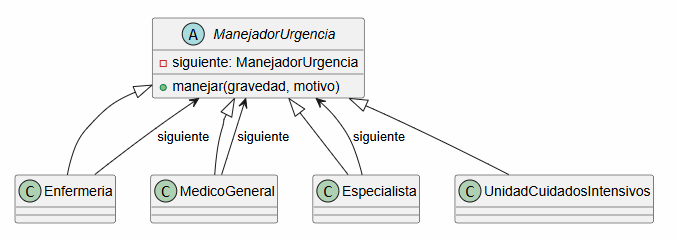

## Por qué Chain of Responsibility y no otro patrón

Se consideró **Strategy**, pero Strategy sirve para elegir **una** de varias formas de resolver el mismo problema, decidido explícitamente por el cliente. Aquí el problema es distinto: no se sabe de antemano cuál nivel resolverá el caso, y potencialmente **más de un** nivel podría necesitar intervenir en secuencia. Chain of Responsibility encaja porque desacopla a quien envía la solicitud (quien no sabe ni necesita saber qué nivel la atenderá) de los manejadores concretos, y permite agregar, quitar o reordenar niveles de atención sin tocar los demás.
